# Baseline

This notebook explains how to make football predictions to maximize your Kicktipp score. We'll guide you through the process step by step, with clear concepts and practical examples.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Prerequisites
Before we start, let's define our approach. We'll model the number of goals scored by each team as random variables and estimate their joint probability distribution. This helps us predict the likelihood of every possible scoreline.

We represent the joint probability of home and away goals as a matrix. Each entry $(i, j)$ shows the probability that the home team scores $i$ goals and the away team scores $j$ goals. Rows are home goals, columns are away goals. This format lets us easily visualize all possible scorelines.

In [2]:
def kicktipp_scoring_rule(scoreline_actual, scoreline_pred):
    home_goals, away_goals = scoreline_actual
    pred_home, pred_away = scoreline_pred
    if home_goals == away_goals:
        # draw
        if pred_home == home_goals and pred_away == away_goals:
            return 4
        elif (pred_home - pred_away) == 0:
            return 2
        else:
            return 0
    else:
        # not a draw
        if pred_home == home_goals and pred_away == away_goals:
            return 4
        elif (pred_home - pred_away) == (home_goals - away_goals):
            return 3
        elif (pred_home > pred_away) == (home_goals > away_goals):
            return 2
        else:
            return 0


# Exact hit
assert kicktipp_scoring_rule((2, 1), (2, 1)) == 4
assert kicktipp_scoring_rule((1, 1), (1, 1)) == 4
assert kicktipp_scoring_rule((0, 1), (0, 1)) == 4

# Correct goal difference
assert kicktipp_scoring_rule((2, 1), (4, 3)) == 3
assert kicktipp_scoring_rule((1, 2), (2, 3)) == 3
assert kicktipp_scoring_rule((1, 1), (0, 0)) == 2

# Correct winner
assert kicktipp_scoring_rule((2, 1), (4, 1)) == 2
assert kicktipp_scoring_rule((0, 1), (2, 5)) == 2

Given these probabilities, we can calculate the expected Kicktipp points for any predicted scoreline, such as 2:1.

In [3]:
# Create a mock probability matrix for a football match outcome
# Each entry [i, j] is the probability of home team scoring i goals and away team scoring j goals
mock_probabilities = np.array(
    [
        [0, 0, 0, 0, 0],
        [3, 2, 1, 0, 0],
        [4, 2, 1, 0, 0],
        [2, 1, 0, 0, 0],
        [1, 0, 0, 0, 0],
    ],
    dtype=float,
)
mock_probabilities /= np.sum(mock_probabilities)  # Normalize to ensure it sums to 1

rewards = [
    mock_probabilities[i, j] * kicktipp_scoring_rule((2, 1), (i, j))
    for i in range(5)
    for j in range(5)
]
expected_reward = np.sum(rewards)
print(f"Expected reward for guessing 2:1 is {expected_reward:.2f}")

Expected reward for guessing 2:1 is 1.94


To speed up calculations, we can build a matrix showing the Kicktipp points for every possible guess.

In [4]:
def generate_kicktipp_score_matrix(scoreline, max_goals=4):
    scores = []
    for hg in range(max_goals + 1):
        for ag in range(max_goals + 1):
            scores.append(kicktipp_scoring_rule(scoreline, (hg, ag)))
    return np.array(scores).reshape((max_goals + 1, max_goals + 1))

Here's what the reward matrix looks like for predicting 2:1.

In [5]:
generate_kicktipp_score_matrix((2, 1))

array([[0, 0, 0, 0, 0],
       [3, 0, 0, 0, 0],
       [2, 4, 0, 0, 0],
       [2, 2, 3, 0, 0],
       [2, 2, 2, 3, 0]])

We can use `np.tensordot` to quickly compute the expected reward, which matches our earlier result.

In [6]:
expected_reward = np.tensordot(
    mock_probabilities, generate_kicktipp_score_matrix((2, 1)), axes=2
)
print(f"Expected reward for guessing 2:1 is {expected_reward:.2f}")

Expected reward for guessing 2:1 is 1.94


So far, we've calculated the expected reward for one guess. To find the best guess, we need to compute the expected reward for every possible scoreline.

In [7]:
expected_rewards = np.zeros((5, 5))
for hg in range(5):
    for ag in range(5):
        expected_rewards[hg, ag] = np.tensordot(
            mock_probabilities, generate_kicktipp_score_matrix((hg, ag)), axes=2
        )
expected_rewards

array([[0.35294118, 0.52941176, 0.47058824, 0.47058824, 0.47058824],
       [2.        , 0.58823529, 0.58823529, 0.47058824, 0.47058824],
       [2.05882353, 1.94117647, 0.47058824, 0.52941176, 0.47058824],
       [1.76470588, 1.88235294, 1.82352941, 0.35294118, 0.52941176],
       [1.64705882, 1.64705882, 1.82352941, 1.82352941, 0.35294118]])

We can optimize this by using numpy arrays. By creating score matrices for all guesses and outcomes, we get a tensor that stays the same regardless of the probabilities.

In [8]:
def generate_kicktipp_score_matrices(max_goals=4):
    matrices = []
    for hg in range(max_goals + 1):
        for ag in range(max_goals + 1):
            matrices.append(
                generate_kicktipp_score_matrix((hg, ag), max_goals=max_goals)
            )
    return np.array(matrices).reshape(
        max_goals + 1, max_goals + 1, max_goals + 1, max_goals + 1
    )


kicktipp_score_matrices = generate_kicktipp_score_matrices()

For example, the tensor contains the same score matrix for a 2:1 prediction as before.

In [9]:
kicktipp_score_matrices[2, 1]

array([[0, 0, 0, 0, 0],
       [3, 0, 0, 0, 0],
       [2, 4, 0, 0, 0],
       [2, 2, 3, 0, 0],
       [2, 2, 2, 3, 0]])

Now, we use `np.einsum` to efficiently calculate expected rewards for all guesses.

In [10]:
expected_rewards = np.einsum("ij,ijkl->kl", mock_probabilities, kicktipp_score_matrices)
expected_rewards

array([[0.47058824, 0.17647059, 0.11764706, 0.11764706, 0.11764706],
       [2.        , 0.70588235, 0.23529412, 0.11764706, 0.11764706],
       [2.05882353, 1.94117647, 0.58823529, 0.17647059, 0.11764706],
       [1.76470588, 1.88235294, 1.82352941, 0.47058824, 0.17647059],
       [1.64705882, 1.64705882, 1.82352941, 1.82352941, 0.47058824]])

These results match our previous calculations. The highest expected reward is for predicting 2:0. Let's wrap this logic in a reusable function.

In [11]:
kicktipp_score_matrices_for_max_goals = {}


def max_expected_reward_guess(probabilities: np.ndarray, max_goals=4):
    # compute the score matrices only once and cache them for later use
    try:
        kicktipp_score_matrices = kicktipp_score_matrices_for_max_goals[max_goals]
    except KeyError:
        kicktipp_score_matrices = generate_kicktipp_score_matrices(max_goals=max_goals)
        kicktipp_score_matrices_for_max_goals[max_goals] = kicktipp_score_matrices

    expected_rewards = np.einsum("ij,ijkl->kl", probabilities, kicktipp_score_matrices)
    max_idx = np.unravel_index(np.argmax(expected_rewards), expected_rewards.shape)
    return [int(max_idx[0]), int(max_idx[1])]


max_expected_reward_guess(mock_probabilities, max_goals=4)

[2, 0]

Next, we'll extend this to predict multiple matches at once by creating a batch function.

In [12]:
def max_expected_reward_guesses(probabilities: np.ndarray, max_goals=4):
    # compute the score matrices only once and cache them for later use
    try:
        kicktipp_score_matrices = kicktipp_score_matrices_for_max_goals[max_goals]
    except KeyError:
        kicktipp_score_matrices = generate_kicktipp_score_matrices(max_goals=max_goals)
        kicktipp_score_matrices_for_max_goals[max_goals] = kicktipp_score_matrices

    expected_rewards = np.einsum(
        "uij,ijkl->ukl", probabilities, kicktipp_score_matrices
    )
    guesses = np.array(
        [
            np.unravel_index(
                np.argmax(expected_rewards[i]),
                expected_rewards.shape[1:],
            )
            for i in range(expected_rewards.shape[0])
        ]
    )
    return guesses


max_expected_reward_guesses(np.array([mock_probabilities, mock_probabilities]))

array([[2, 0],
       [2, 0]])

We've covered how to select the best guess based on expected reward. But how do we compute these probabilities?
In the next section, we'll build a simple model using past outcomes, without match-specific information.

## Simple Baseline Model

In [13]:
class BaselineModel:
    def __init__(self, max_goals=4):
        self.max_goals = max_goals

    def fit(self, df_matches):
        scorelines = df_matches[["home_goals", "away_goals"]].to_numpy()
        scorelines = np.clip(scorelines, 0, self.max_goals)
        counts = np.zeros((self.max_goals + 1, self.max_goals + 1), dtype=int)
        for hg, ag in scorelines:
            counts[hg, ag] += 1
        self.counts_ = counts
        self.probabilities_ = counts / np.sum(counts)

    def predict_proba(self, df_matches):
        n = df_matches.shape[0]
        probabilities = np.broadcast_to(
            self.probabilities_, (n,) + self.probabilities_.shape
        )
        return probabilities

    def predict(self, df_matches):
        probabilities = self.predict_proba(df_matches)
        guesses = max_expected_reward_guesses(probabilities, max_goals=self.max_goals)
        return guesses

Let's load the data, fit the model on seasons before 2024, and evaluate its performance on the 2024 Bundesliga season.

In [20]:
df_matches = pd.read_pickle("data/matches.pkl")
df_matches = df_matches[df_matches["season"] < 2025]  # Use only past seasons
df_matches = df_matches[df_matches["league"] == "bl1"]
df_train = df_matches[df_matches["season"] < 2024]
df_test = df_matches[df_matches["season"] == 2024]

model = BaselineModel(max_goals=4)
model.fit(df_train)

Let's visualize the joint distribution of scorelines learned by the model.

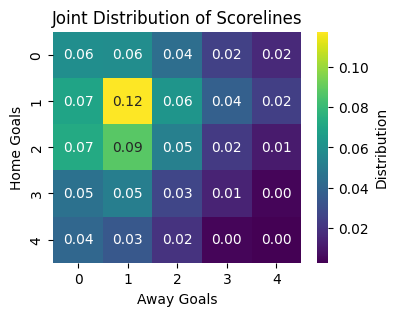

In [21]:
plt.figure(figsize=(4, 3))
sns.heatmap(
    model.probabilities_,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Distribution"},
)
plt.xlabel("Away Goals")
plt.ylabel("Home Goals")
plt.title("Joint Distribution of Scorelines")
plt.show()

The most frequent scoreline is 1:1. High-scoring games are rare, and home teams tend to score more. Let's check the expected rewards for these probabilities.

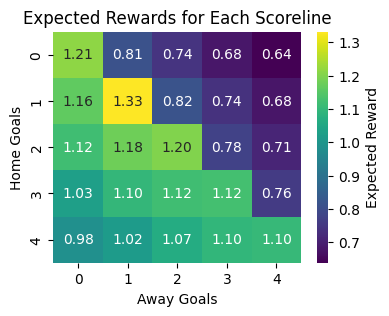

In [22]:
expected_rewards = expected_rewards = np.einsum(
    "ij,ijkl->kl", model.probabilities_, kicktipp_score_matrices
)

plt.figure(figsize=(4, 3))
sns.heatmap(
    expected_rewards,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Expected Reward"},
)
plt.xlabel("Away Goals")
plt.ylabel("Home Goals")
plt.title("Expected Rewards for Each Scoreline")
plt.show()

Betting on the home team yields higher expected rewards, but the best is usually 1:1. The model will predict this scoreline for all matches.

In [23]:
predictions = model.predict(df_test)
predictions[:5]

array([[1, 1],
       [1, 1],
       [1, 1],
       [1, 1],
       [1, 1]])

Let's calculate the Kicktipp points the model would have earned in 2024.

In [24]:
def compute_kicktipp_points(df_matches, predictions):
    actual_scorelines = df_matches[["home_goals", "away_goals"]].to_numpy()
    points = [
        kicktipp_scoring_rule(actual, pred)
        for actual, pred in zip(actual_scorelines, predictions)
    ]
    return int(np.sum(points))


compute_kicktipp_points(df_test, predictions)

428

A score of 428 is quite reasonable. Let's also check performance in other seasons using cross-validation.

In [25]:
class CrossValidationResult:
    scores: list[tuple[int, int]]

    def __init__(self):
        self.mean_score = 0.0
        self.scores = []

    @property
    def score_mean(self):
        return np.mean([score for year, score in self.scores]).item()

    @property
    def score_std(self):
        return np.std([score for year, score in self.scores]).item()


def cross_validate_model(model, df_matches):
    years = df_matches["season"].unique()
    min_year, max_year = int(np.min(years)), int(np.max(years))
    result = CrossValidationResult()
    for year in range(min_year + 1, max_year + 1):
        df_train = df_matches[df_matches["season"] < year]
        df_test = df_matches[df_matches["season"] == year]
        model.fit(df_train)
        predictions = model.predict(df_test)
        score = compute_kicktipp_points(df_test, predictions)
        result.scores.append((year, score))
    return result


cv_result = cross_validate_model(BaselineModel(max_goals=4), df_matches)
cv_result.score_mean, cv_result.score_std

(409.57142857142856, 18.1608459750809)

Across all seasons, the model performs slightly worse but remains competitive.